In [ ]:
!pip install --no-deps transformers==4.53.1
!pip install --no-deps --upgrade timm

In [ ]:
import os
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth
else:
    !pip install --no-deps bitsandbytes accelerate xformers==0.0.29.post3 peft trl triton cut_cross_entropy unsloth_zoo
    !pip install sentencepiece protobuf "datasets>=3.4.1,<4.0.0" huggingface_hub hf_transfer
    !pip install --no-deps unsloth

In [ ]:
from unsloth import FastVisionModel
import torch
model, processor = FastVisionModel.from_pretrained(
    "unsloth/gemma-3n-E2B-it",
    load_in_4bit = True,
    use_gradient_checkpointing = "unsloth",
)

==((====))==  Unsloth 2025.8.1: Fast Gemma3N patching. Transformers: 4.53.1.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.6.0+cu124. CUDA: 7.5. CUDA Toolkit: 12.4. Triton: 3.2.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.29.post3. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Gemma3N does not support SDPA - switching to eager!


ValueError: Some modules are dispatched on the CPU or the disk. Make sure you have enough GPU RAM to fit the quantized model. If you want to dispatch the model on the CPU or the disk while keeping these modules in 32-bit, you need to set `llm_int8_enable_fp32_cpu_offload=True` and pass a custom `device_map` to `from_pretrained`. Check https://huggingface.co/docs/transformers/main/en/main_classes/quantization#offload-between-cpu-and-gpu for more details. 

We now add LoRA adapters for parameter efficient fine-tuning, allowing us to train only 1% of all model parameters efficiently.

We will fine-tune the vision component and the language component both for gemma3n. Additionally, you can choose to fine-tune the attention modules, the MLP layers, or both!

In [ ]:
model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers     = True,
    finetune_language_layers   = True,
    finetune_attention_modules = True,
    finetune_mlp_modules       = True,
    r = 16,
    lora_alpha = 16,
    lora_dropout = 0,
    bias = "none",
    random_state = 3407,
    use_rslora = False,
    loftq_config = None,
    target_modules = "all-linear",
    modules_to_save=[
        "lm_head",
        "embed_tokens",
    ],
)

RuntimeError: Unsloth: You already added LoRA adapters to your model!

In [ ]:
from datasets import load_dataset

dataset = load_dataset("ashraq/fashion-product-images-small", split="train")

In [ ]:
dataset

Dataset({
    features: ['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName', 'image'],
    num_rows: 44072
})

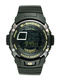

In [ ]:
dataset[20]["image"]

In [ ]:
dataset[20]["productDisplayName"]

'CASIO G-Shock Men Black Digital Watch G-7710-1DR G223'

In [ ]:
instruction = "You are a fashion product expert. Describe accurately what you see in this image."
def convert_to_conversation(sample):
    conversation = [
        {
            "role": "user",
            "content": [
                {"type": "text", "text": instruction},
                {"type": "image", "image": sample["image"]},
            ],
        },
        {"role": "assistant", "content": [{"type": "text", "text": sample["productDisplayName"]}]},
    ]
    return {"messages": conversation}
pass

Let's convert the dataset into the "correct" format for finetuning:

In [ ]:
converted_dataset = [convert_to_conversation(sample) for sample in dataset]

The first example is now structured like below:

In [ ]:
converted_dataset[20]

{'messages': [{'role': 'user',
   'content': [{'type': 'text',
     'text': 'You are a fashion product expert. Describe accurately what you see in this image.'},
    {'type': 'image',
     'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=60x80>}]},
  {'role': 'assistant',
   'content': [{'type': 'text',
     'text': 'CASIO G-Shock Men Black Digital Watch G-7710-1DR G223'}]}]}

Before fine-tuning, let us evaluate the base model's performance. We do not expect strong results, as it has not encountered this chat template before.

In [ ]:
FastVisionModel.for_inference(model)
image = dataset[20]["image"]
instruction = "You are a fashion product expert. Describe accurately what you see in this image."
messages = [
    {
        "role": "user",
        "content": [{"type": "image"}, {"type": "text", "text": instruction}],
    }
]
input_text = processor.apply_chat_template(messages, add_generation_prompt=True)
if image.mode == 'L':
    image = image.convert('RGB')
inputs = processor(
    image,
    input_text,
    add_special_tokens=False,
    return_tensors="pt",
).to("cuda")
from transformers import TextStreamer
text_streamer = TextStreamer(processor, skip_prompt=True)
result = model.generate(**inputs, streamer = text_streamer, max_new_tokens = 256,
                        use_cache=True, temperature = 1.0, top_p = 0.95, top_k = 64)

A black digital watch with a black strap is shown in a close-up shot. The watch face is dark gray with yellow accents. The digital display shows the time as 9:45. The watch has a rounded black bezel and a black strap. The watch is positioned on a white background.<end_of_turn>


In [ ]:
processor.tokenizer.model_max_length = 2048
trainer = SFTTrainer(
    model=model,
    train_dataset=converted_dataset,
    processing_class=processor.tokenizer,
    data_collator=UnslothVisionDataCollator(model, processor, resize=512),
    args = SFTConfig(
        per_device_train_batch_size = 1,
        gradient_accumulation_steps = 4,
        gradient_checkpointing = False,
        max_grad_norm = 0.3,
        warmup_steps = 5,
        max_steps = 60,
        learning_rate = 2e-4,
        logging_steps = 1,
        save_strategy="steps",
        optim = "adamw_torch_fused",
        weight_decay = 0.01,
        lr_scheduler_type = "cosine",
        seed = 3407,
        output_dir = "outputs",
        report_to = "none",
        remove_unused_columns = False,
        dataset_text_field = "",
        dataset_kwargs = {"skip_prepare_dataset": True},
    )
)


In [ ]:
trainer_stats = trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 44,072 | Num Epochs = 1 | Total steps = 60
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 4 x 1) = 4
 "-____-"     Trainable parameters = 21,135,360 of 5,460,573,632 (0.39% trained)


Step,Training Loss
1,2.815700
2,3.292200
3,3.090500
4,3.222000
5,3.242100
6,3.246500
7,2.965300
8,3.217900
9,3.123600
10,2.220800


In [ ]:
from transformers import TextStreamer
FastVisionModel.for_inference(model)
image = dataset[20]["image"]
instruction = "You are a fashion product expert. Describe accurately what you see in this image."
messages = [
    {
        "role": "user",
        "content": [{"type": "image"}, {"type": "text", "text": instruction}],
    }
]
input_text = processor.apply_chat_template(messages, add_generation_prompt=True)
if image.mode == 'L':
    image = image.convert('RGB')
inputs = processor(
    image,
    input_text,
    add_special_tokens=False,
    return_tensors="pt",
).to("cuda")
text_streamer = TextStreamer(processor, skip_prompt=True)
result = model.generate(**inputs, streamer = text_streamer, max_new_tokens = 256,
                        use_cache=True, temperature = 1.0, top_p = 0.95, top_k = 64)

Casio Men Digital Watch<end_of_turn>


In [ ]:
model.save_pretrained("lora_model")
processor.save_pretrained("lora_model")

['lora_model/processor_config.json']

In [ ]:
from transformers import TextStreamer
if False:
    from unsloth import FastVisionModel
    model, processor = FastVisionModel.from_pretrained(
        model_name="lora_model",
        load_in_4bit=True,
    )
    FastVisionModel.for_inference(model)
FastVisionModel.for_inference(model)
sample = dataset[20]
image = sample["image"].convert("RGB")
messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "text",
                "text": sample["productDisplayName"],
            },
            {
                "type": "image",
            },
        ],
    },
]
input_text = processor.apply_chat_template(messages, add_generation_prompt=True)
inputs = processor(
    image,
    input_text,
    add_special_tokens=False,
    return_tensors="pt",
).to("cuda")
text_streamer = TextStreamer(processor.tokenizer, skip_prompt=True)
_ = model.generate(**inputs, streamer = text_streamer, max_new_tokens = 128,
                   use_cache=True, temperature = 1.0, top_p = 0.95, top_k = 64)

CASIO G-Shock Men Black Digital Watch G-7710-1DR G223<end_of_turn>


In [ ]:
if False: model.save_pretrained_merged("unsloth_finetune", processor,)
if False: model.push_to_hub_merged("YOUR_USERNAME/unsloth_finetune", processor, token = "PUT_HERE")

In [ ]:
from transformers import TextStreamer
FastVisionModel.for_inference(model)
image = dataset[20]["image"]
instruction = "You are a fashion stylist. Based on the image, describe the product in detail, including its type, style, color, and intended gender."
messages = [
    {
        "role": "user",
        "content": [{"type": "image"}, {"type": "text", "text": instruction}],
    }
]
input_text = processor.apply_chat_template(messages, add_generation_prompt=True)
if image.mode == 'L':
    image = image.convert('RGB')
inputs = processor(
    image,
    input_text,
    add_special_tokens=False,
    return_tensors="pt",
).to("cuda")
text_streamer = TextStreamer(processor, skip_prompt=True)
result = model.generate(**inputs, streamer = text_streamer, max_new_tokens = 256,
                        use_cache=True, temperature = 1.0, top_p = 0.95, top_k = 64)

Casio Men's Digital Watch<end_of_turn>


In [ ]:
from transformers import TextStreamer
FastVisionModel.for_inference(model)
image = dataset[20]["image"]
instruction = "You are a fashion product expert. Describe accurately what you see in this image."
messages = [
    {
        "role": "user",
        "content": [{"type": "image"}, {"type": "text", "text": instruction}],
    }
]
input_text = processor.apply_chat_template(messages, add_generation_prompt=True)
if image.mode == 'L':
    image = image.convert('RGB')
inputs = processor(
    image,
    input_text,
    add_special_tokens=False,
    return_tensors="pt",
).to("cuda")
text_streamer = TextStreamer(processor, skip_prompt=True)
result = model.generate(**inputs, streamer = text_streamer, max_new_tokens = 256,
                        use_cache=True, temperature = 1.0, top_p = 0.95, top_k = 64)

Casio G-Shock Men's Black Digital Watch<end_of_turn>


In [ ]:
###################################################

In [ ]:
! pip install unsloth transformers timm datasets torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━ 276.5/363.4 MB 23.1 MB/s eta 0:00:04
ERROR: Operation cancelled by user
